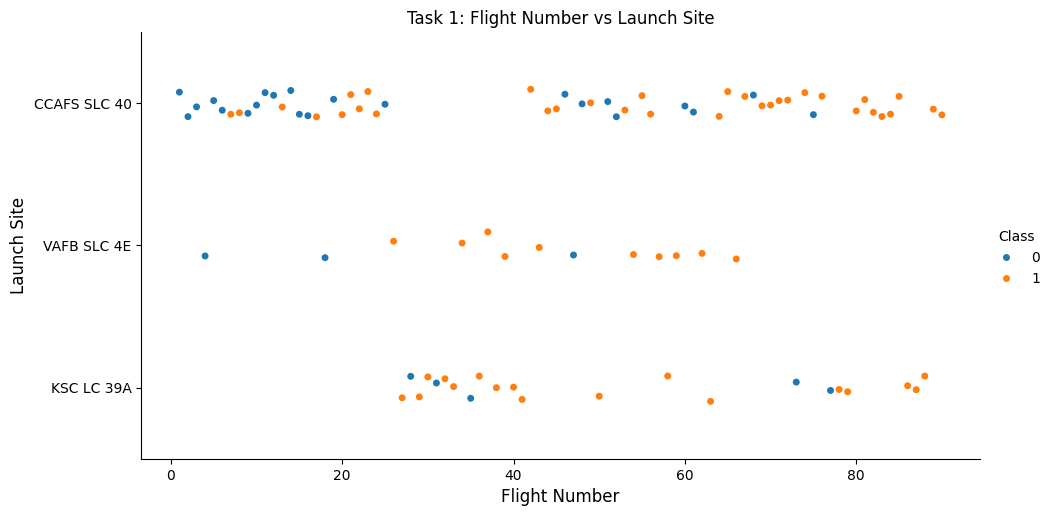

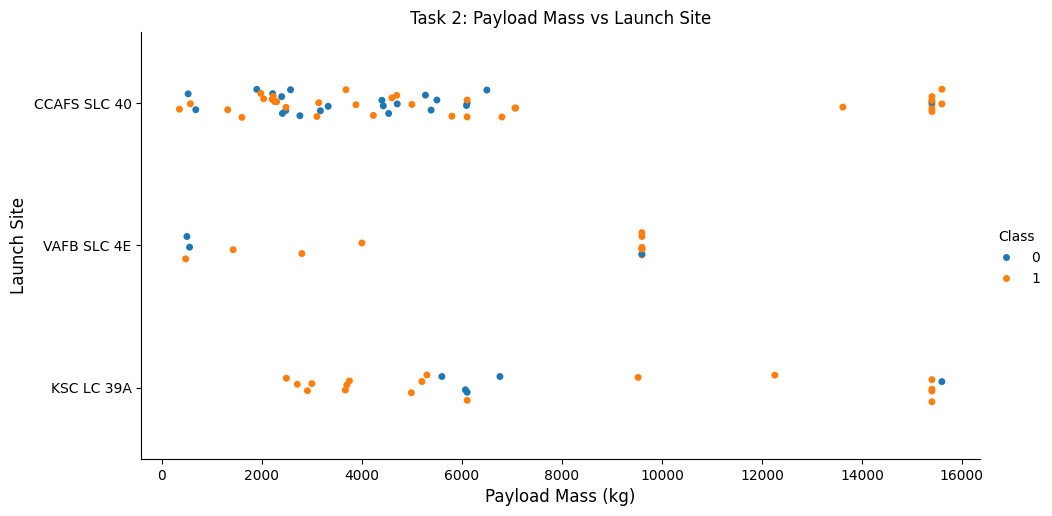

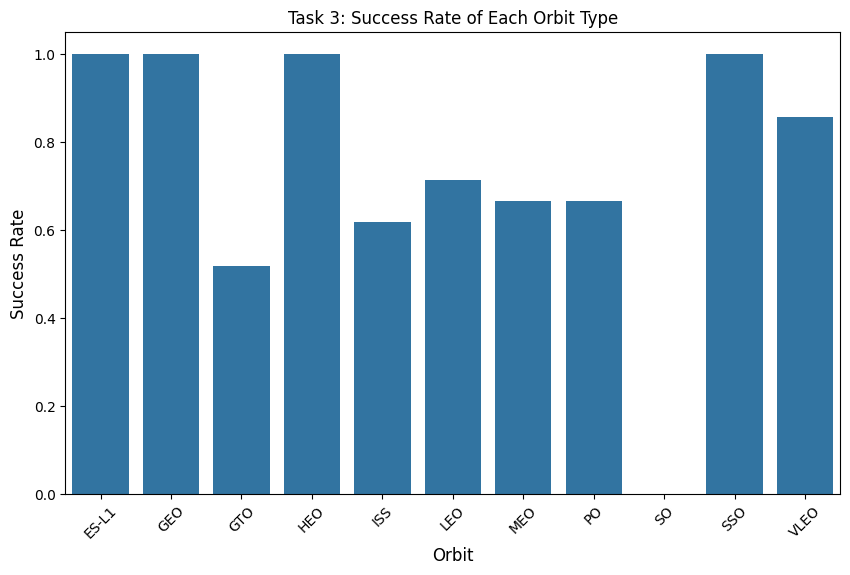

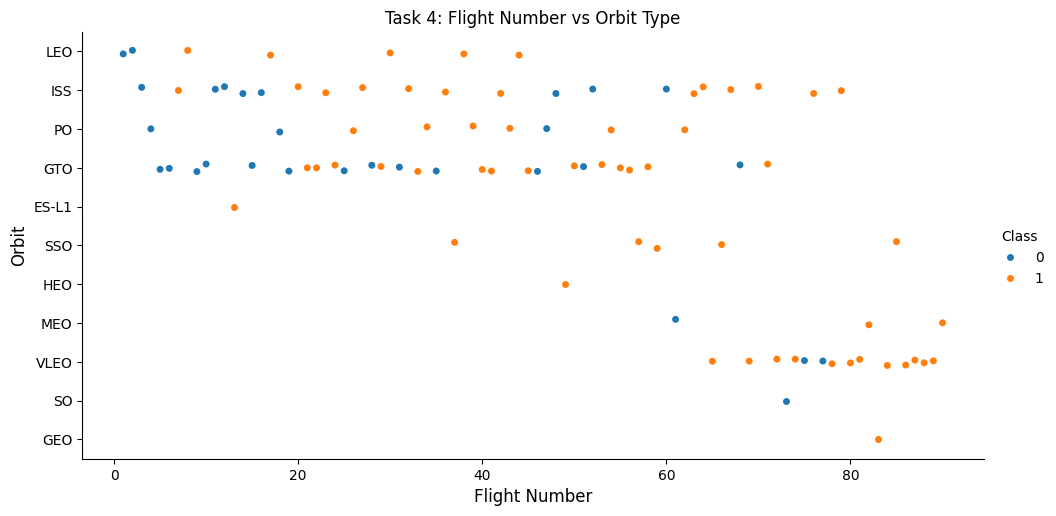

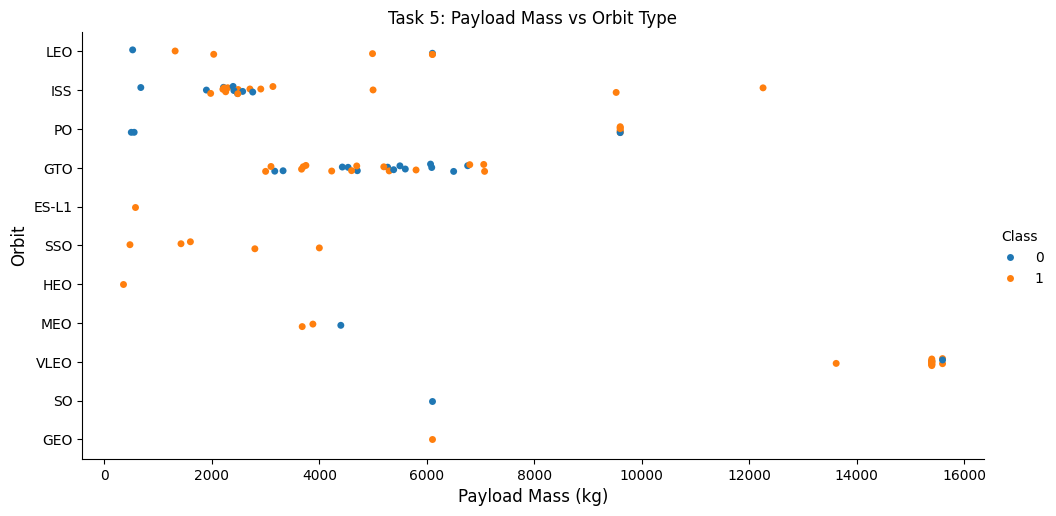

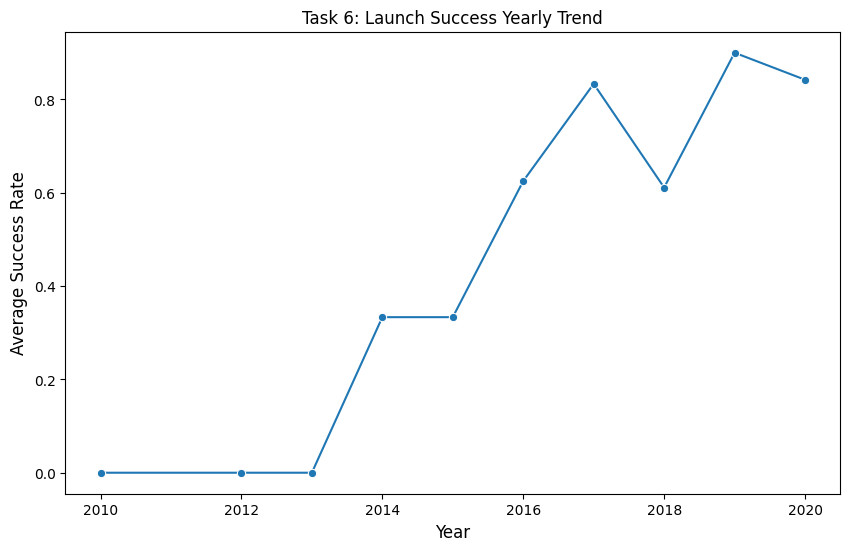

Task 7 and Task 8 Output:
   FlightNumber  PayloadMass  Flights  GridFins  Reused  Legs  Block  \
0           1.0  6104.959412      1.0       0.0     0.0   0.0    1.0   
1           2.0   525.000000      1.0       0.0     0.0   0.0    1.0   
2           3.0   677.000000      1.0       0.0     0.0   0.0    1.0   
3           4.0   500.000000      1.0       0.0     0.0   0.0    1.0   
4           5.0  3170.000000      1.0       0.0     0.0   0.0    1.0   

   ReusedCount  Orbit_ES-L1  Orbit_GEO  ...  Serial_B1048  Serial_B1049  \
0          0.0          0.0        0.0  ...           0.0           0.0   
1          0.0          0.0        0.0  ...           0.0           0.0   
2          0.0          0.0        0.0  ...           0.0           0.0   
3          0.0          0.0        0.0  ...           0.0           0.0   
4          0.0          0.0        0.0  ...           0.0           0.0   

   Serial_B1050  Serial_B1051  Serial_B1054  Serial_B1056  Serial_B1058  \
0           0.0

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(URL)

sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.title("Task 1: Flight Number vs Launch Site")
plt.show()

sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=2)
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.title("Task 2: Payload Mass vs Launch Site")
plt.show()

success_rate = df.groupby("Orbit")["Class"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(x="Orbit", y="Class", data=success_rate)
plt.xlabel("Orbit", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.title("Task 3: Success Rate of Each Orbit Type")
plt.xticks(rotation=45)
plt.show()

sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=2)
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Orbit", fontsize=12)
plt.title("Task 4: Flight Number vs Orbit Type")
plt.show()

sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=2)
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Orbit", fontsize=12)
plt.title("Task 5: Payload Mass vs Orbit Type")
plt.show()

df["Year"] = pd.to_datetime(df["Date"]).dt.year
yearly_success = df.groupby("Year")["Class"].mean().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(x="Year", y="Class", data=yearly_success, marker="o")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Success Rate", fontsize=12)
plt.title("Task 6: Launch Success Yearly Trend")
plt.show()

features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]

features_one_hot = pd.get_dummies(
    features,
    columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial']
)

features_one_hot = features_one_hot.astype('float64')

print("Task 7 and Task 8 Output:")
print(features_one_hot.head())
print("\nData types after casting:")
print(features_one_hot.dtypes)

features_one_hot.to_csv("dataset_part_3.csv", index=False)
print("\ndataset_part_3.csv saved successfully")